A) Considerando o conjunto de dados do Estudo Dirigido 2, discuta quais possíveis métodos de pré-processamento de dados poderiam ser aplicados desde o processo de coleta até a etapa de preparação para descoberta de conhecimento. Apresente textualmente suas motivações para o processo escolhido. 

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [18]:
df = pd.read_csv(
    'dados_reduzidos.csv',
    sep=';',
    decimal=',',
)
df.head()

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,...,bairro,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,estacao_prox,linha_prox,dist,lat,lon
0,526,189900,32,2,1,180.0,0,1,0,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,SÃO MATEUS,PRATA,6822.823684,-23.583879,-46.417548
1,734,221110,43,2,1,250.0,0,1,0,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4682.709841,-23.543535,-46.425492
2,738,219990,43,1,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
3,753,219990,43,2,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
4,924,220000,41,2,1,300.0,0,1,1,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,3313.918703,-23.557799,-46.443523


In [19]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2499 non-null   int64  
 1   valor_total       2499 non-null   int64  
 2   area_util         2499 non-null   int64  
 3   quartos           2499 non-null   int64  
 4   vagas             2499 non-null   int64  
 5   valor_condominio  2264 non-null   float64
 6   suites            2499 non-null   int64  
 7   banheiros         2499 non-null   int64  
 8   piscina           2499 non-null   int64  
 9   academia          2499 non-null   int64  
 10  quadra            2499 non-null   int64  
 11  link              2499 non-null   str    
 12  bairro            2499 non-null   str    
 13  qtd_dados_bairro  2492 non-null   float64
 14  media_idh         2499 non-null   float64
 15  expectativa_vida  2499 non-null   float64
 16  renda_percapita   2499 non-null   float64
 17  estaca

In [20]:
df.describe()

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,quadra,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,dist,lat,lon
count,2499.000000,2.499000e+03,2499.000000,2499.000000,2499.000000,2264.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000,2492.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000
mean,1290.477791,5.480852e+05,71.316927,2.276911,1.226491,1720.326413,0.647459,1.742297,0.370948,0.165266,0.306523,21.928973,0.792821,77.035595,1583.835864,2850.631882,-23.564247,-46.615783
std,740.952704,5.544487e+05,44.756816,0.628384,1.077428,28048.547320,0.805409,1.022180,0.483155,0.371495,0.461142,9.753988,0.057991,2.270557,1108.707809,2740.544877,0.067111,0.101202
min,1.000000,8.000000e+04,22.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.692258,72.411290,522.515294,31.324895,-23.882700,-46.805753
25%,649.500000,2.650000e+05,49.000000,2.000000,1.000000,350.000000,0.000000,1.000000,0.000000,0.000000,0.000000,15.000000,0.747778,75.376296,863.321429,926.379634,-23.603639,-46.692986
50%,1292.000000,3.800000e+05,60.000000,2.000000,1.000000,486.000000,0.000000,1.000000,0.000000,0.000000,0.000000,21.000000,0.788200,77.182500,1243.473077,2030.330924,-23.553274,-46.634285
75%,1932.500000,5.985000e+05,74.000000,3.000000,1.000000,650.000000,1.000000,2.000000,1.000000,0.000000,1.000000,28.000000,0.826400,78.438750,1788.620000,3844.249552,-23.513279,-46.541624
max,2570.000000,1.200000e+07,640.000000,5.000000,39.000000,857000.000000,4.000000,8.000000,1.000000,1.000000,1.000000,51.000000,0.944667,81.950000,6721.230000,26101.126560,-23.402091,-46.376155


O conjunto de dados é composto por 2.499 registros e 21 atributos. Embora a quantidade de variáveis não seja elevada, é importante avaliar a relevância e a qualidade das informações fornecidas por cada atributo em relação à variável-alvo que se deseja predizer. Durante a análise exploratória, foram identificados valores ausentes nos atributos valor_condominio e qtd_dados_bairro, com 235 e 7 registros nulos, respectivamente. Dessa forma, torna-se necessária a definição de uma estratégia de tratamento desses dados, como imputação ou remoção dos registros afetados. Também foram observados outliers na variável valor_total.  Além disso, os atributos media_idh e expectativa_vida podem ser transformados em variáveis categóricas intervalares permitindo a criação de faixas que facilitem a interpretação dos dados.

In [21]:
#quantidade de valores nulos
print(df.isnull().sum())

df_original = df.copy()

id                    0
valor_total           0
area_util             0
quartos               0
vagas                 0
valor_condominio    235
suites                0
banheiros             0
piscina               0
academia              0
quadra                0
link                  0
bairro                0
qtd_dados_bairro      7
media_idh             0
expectativa_vida      0
renda_percapita       0
estacao_prox          0
linha_prox            0
dist                  0
lat                   0
lon                   0
dtype: int64


In [22]:
#Substitui os valores nulos pela mediana

df["valor_condominio"] = df["valor_condominio"].fillna(
    df["valor_condominio"].median()
)

df["qtd_dados_bairro"] = df["qtd_dados_bairro"].fillna(
    df["qtd_dados_bairro"].median()
)

In [23]:
# análise de outliers

Q1 = df["valor_total"].quantile(0.25)
Q3 = df["valor_total"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[
    (df["valor_total"] < lim_inf) |
    (df["valor_total"] > lim_sup)
]

print("Quantidade de outliers:", len(outliers))



Quantidade de outliers: 236


In [24]:
df_sem_outliers = df[
    (df["valor_total"] >= lim_inf) &
    (df["valor_total"] <= lim_sup)
]
print("Registros originais:", len(df))
print("Registros após remoção:", len(outliers))

Registros originais: 2499
Registros após remoção: 236


In [25]:
df["valor_m2"] = df["valor_total"] / df["area_util"]

Q1 = df["valor_m2"].quantile(0.25)
Q3 = df["valor_m2"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_m2 = df[
    (df["valor_m2"] < lim_inf) |
    (df["valor_m2"] > lim_sup)
]

print("Outliers valor/m²:", len(outliers_m2))

Outliers valor/m²: 93


In [26]:
df_sem_outliers_m2 = df[
    (df["valor_m2"] >= lim_inf) &
    (df["valor_m2"] <= lim_sup)
]

print("Registros originais:", len(df))
print("Registros após remoção:", len(df_sem_outliers_m2))

Registros originais: 2499
Registros após remoção: 2406


In [27]:
# Discretização do IDH
df["faixa_idh"] = pd.cut(
    df["media_idh"],
    bins=[0, 0.55, 0.70, 0.80, 1.0],
    labels=[
        "Muito Baixo",
        "Médio",
        "Alto",
        "Muito Alto"
    ]
)

# Discretização da expectativa de vida
df["faixa_expectativa_vida"] = pd.cut(
    df["expectativa_vida"],
    bins=[0, 65, 75, 85, 100],
    labels=[
        "Baixa",
        "Média",
        "Alta",
        "Muito Alta"
    ]
)

df.drop(columns=["media_idh", "expectativa_vida"], inplace=True)

In [28]:
scaler = MinMaxScaler()

colunas = ["valor_total", "valor_condominio", "area_util"]

df[colunas] = scaler.fit_transform(df[colunas])

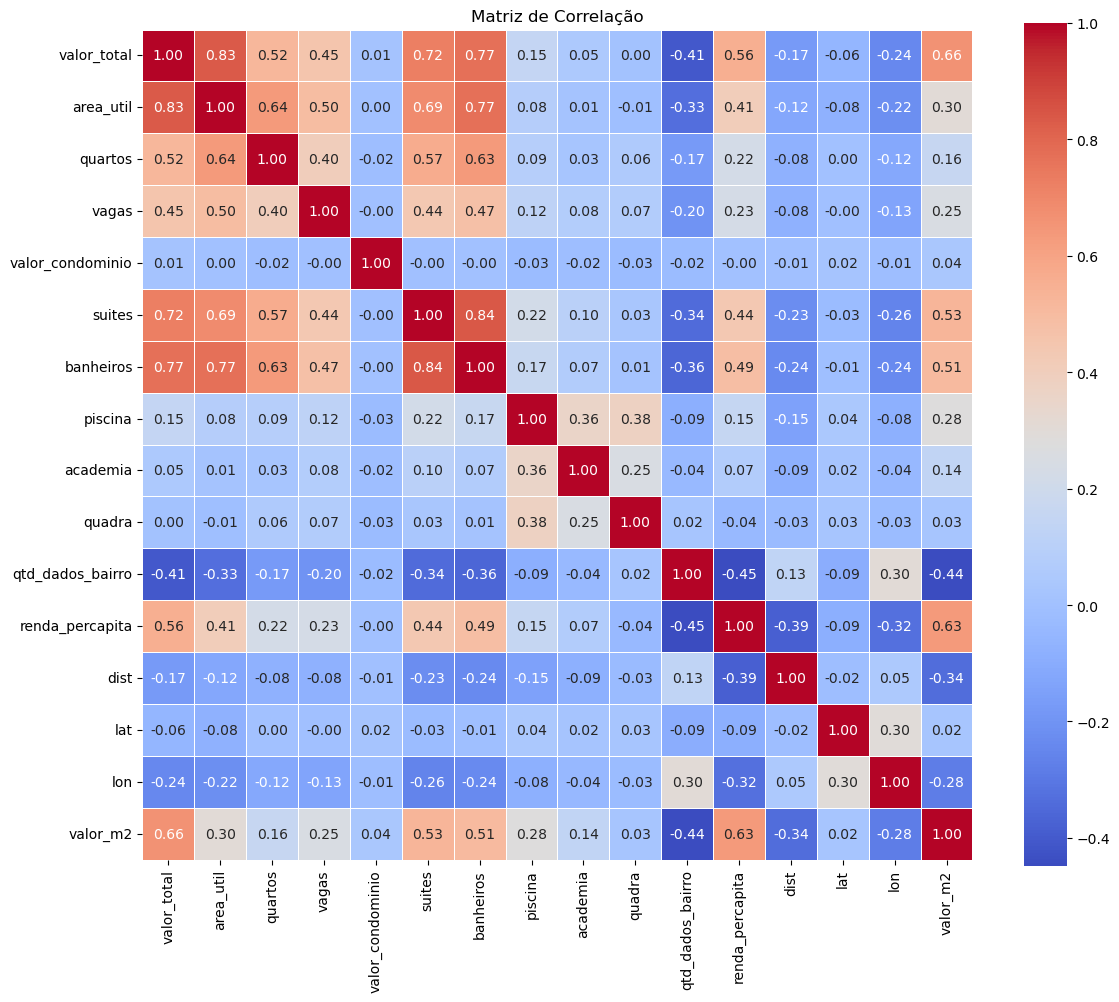

In [29]:
corr = df.drop(columns=["id"]).corr(numeric_only=True)
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

Caso a variável valor_total fosse definida como target em um problema de aprendizado supervisionado, seria interessante realizar uma etapa de seleção de atributos, priorizando as variáveis que apresentam maior correlação com ela. Entre os atributos potencialmente mais relevantes estariam area_util, suite e banheiros. Além disso, seria importante analisar a correlação entre essas próprias variáveis independentes, a fim de identificar possíveis casos de multicolinearidade. 

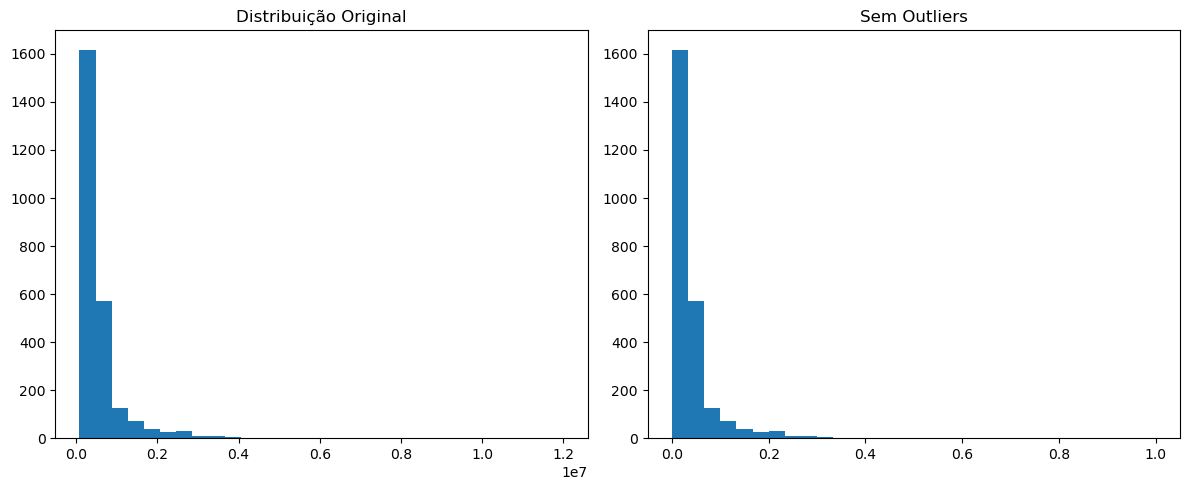

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(df_original["valor_total"], bins=30)
ax[0].set_title("Distribuição Original")

ax[1].hist(df["valor_total"], bins=30)
ax[1].set_title("Sem Outliers")

plt.tight_layout()
plt.show()

In [31]:
print("Antes:")
print(df_original["valor_total"].describe()[["mean","50%"]])

print("\nDepois:")
print(df_sem_outliers["valor_total"].describe()[["mean","50%"]])

Antes:
mean    548085.204882
50%     380000.000000
Name: valor_total, dtype: float64

Depois:
mean    407567.688025
50%     350000.000000
Name: valor_total, dtype: float64


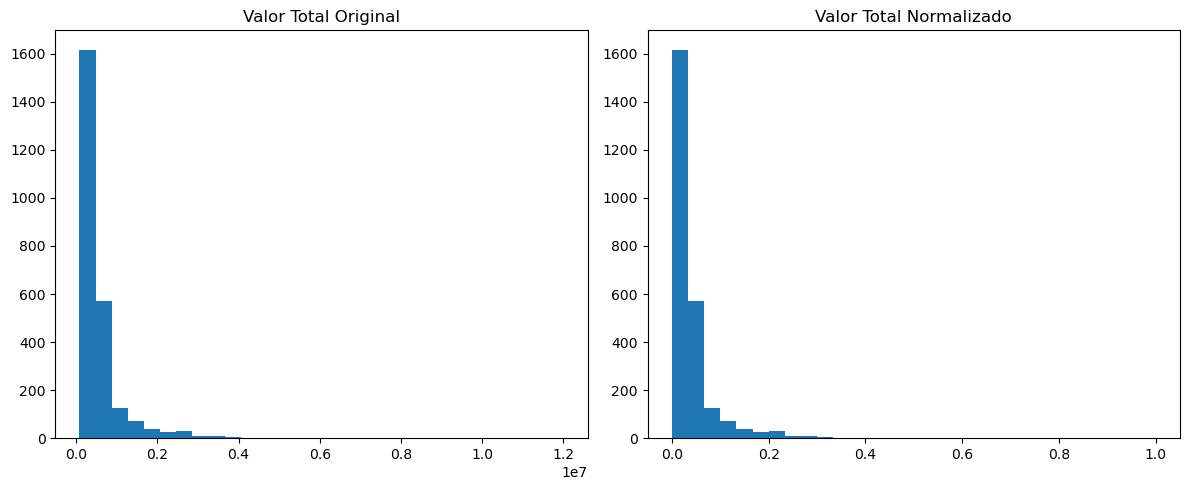

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(df_original["valor_total"], bins=30)
ax[0].set_title("Valor Total Original")

ax[1].hist(df["valor_total"], bins=30)
ax[1].set_title("Valor Total Normalizado")

plt.tight_layout()
plt.show()

Após a remoção dos outliers da variável valor_total, a média do imóvel foi alterda de forma significativa. A média antes do tratamento era de R$ 548.085,20 e após o tratamento a média possu para R$ 407.567,69, representando uma redução maior que 20%. Já a mediana apresentou uma variação menor, passando de R$ 380.000,00 para R$ 350.000,00. Esse resultado reforça a observação feita no Estudo 2 sobre o valor dos imóveis estarem superestimados dedvdo à presença de apartamentos de luxo em bairros com IDH alto, como Pinheiros. Entretanto, remover outliers não é uma boa prática sem antes investigar a causa raiz e também existe a opção de transformar os dados